# Анализ спроса на специалистов с ИИ-навыками на российском рынке труда

**Цель исследования:** На основе данных о вакансиях определить реальный спрос на ИИ-компетенции для помощи бизнесу в принятии кадровых решений.

**Ключевые вопросы:**
- В каких секторах экономики наиболее активно ищут специалистов с ИИ-навыками?
- Каковы показатели спроса по федеральным округам и субъектам РФ?
- Какие компании являются лидерами по найму?
- Как меняется общий объем и структура спроса во времени?

**Используемые данные:** Датасет вакансий с сайтов hh.ru и др. за период 2022-2024 гг., содержащих требования к ИИ-навыкам.

**Инструменты:** Python (pandas, matplotlib, seaborn), Jupyter Notebook.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style('whitegrid') 

sns.set_palette('muted')

Импортируем библиотеки, выбираем красивые настройки для будущих графиков

In [21]:
df = pd.read_csv('Вакансии_ИИ_с навыками.csv')

Читаем файл с вакансиями

# Первый шаг

In [22]:
df.head()

,data_source,id,link,date_published,name,description,salary,salary_currency,salary_gross,experience,...,schedule_label,employment_label,country_name,region_name,region_district_name,region_city_name,hard_skills,soft_skills,Категория,skills
0,hh,72038834.0,https://hh.ru/vacancy/72038834,11/8/2022 12:08:33 AM,Senior Golang Developer (DS Works),Вам предстоит: Разработка международной платф...,0,NaN,0,3-6,...,Полный день,Полная занятость,Россия,Москва,Центральный,Москва,"'SQL','PostgreSQL','Apache Kafka','Docker','Ku...",[],IT,SQL
1,hh,72038834.0,https://hh.ru/vacancy/72038834,11/8/2022 12:08:33 AM,Senior Golang Developer (DS Works),Вам предстоит: Разработка международной платф...,0,NaN,0,3-6,...,Полный день,Полная занятость,Россия,Москва,Центральный,Москва,"'SQL','PostgreSQL','Apache Kafka','Docker','Ku...",[],IT,PostgreSQL
2,hh,72038834.0,https://hh.ru/vacancy/72038834,11/8/2022 12:08:33 AM,Senior Golang Developer (DS Works),Вам предстоит: Разработка международной платф...,0,NaN,0,3-6,...,Полный день,Полная занятость,Россия,Москва,Центральный,Москва,"'SQL','PostgreSQL','Apache Kafka','Docker','Ku...",[],IT,Apache Kafka
3,hh,72038834.0,https://hh.ru/vacancy/72038834,11/8/2022 12:08:33 AM,Senior Golang Developer (DS Works),Вам предстоит: Разработка международной платф...,0,NaN,0,3-6,...,Полный день,Полная занятость,Россия,Москва,Центральный,Москва,"'SQL','PostgreSQL','Apache Kafka','Docker','Ku...",[],IT,Docker
4,hh,72038834.0,https://hh.ru/vacancy/72038834,11/8/2022 12:08:33 AM,Senior Golang Developer (DS Works),Вам предстоит: Разработка международной платф...,0,NaN,0,3-6,...,Полный день,Полная занятость,Россия,Москва,Центральный,Москва,"'SQL','PostgreSQL','Apache Kafka','Docker','Ku...",[],IT,Kubernetes


Смотрим первые 5 строк для понимания какие есть данные в этом датасете

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79941 entries, 0 to 79940
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   data_source             79941 non-null  object 
 1   id                      79938 non-null  float64
 2   link                    79941 non-null  object 
 3   date_published          79941 non-null  object 
 4   name                    79941 non-null  object 
 5   description             79941 non-null  object 
 6   salary                  79941 non-null  int64  
 7   salary_currency         37945 non-null  object 
 8   salary_gross            79941 non-null  int64  
 9   experience              79941 non-null  object 
 10  employer_name           79849 non-null  object 
 11  employer_industry_name  34060 non-null  object 
 12  languages               79941 non-null  object 
 13  education               79941 non-null  object 
 14  accept_kids             79941 non-null

Собираем информацию по датасету, изучаем наличие пропусков, и названия столбцов. Как мы видим по признаку employer_industry_name есть большое количество пропусков. Этот признак не влияет на наш анализ, поэтому от него можно отказаться.

Также для уменьшения размера датасета для удобства работы с ним, можно отказаться еще от нескольких признаков, которые не повлияют на будующий анализ.

In [24]:
new_df = df[['Категория','region_name', 'region_district_name', 'employer_name', 'date_published']].copy()
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79941 entries, 0 to 79940
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Категория             79941 non-null  object
 1   region_name           79941 non-null  object
 2   region_district_name  79941 non-null  object
 3   employer_name         79849 non-null  object
 4   date_published        79941 non-null  object
dtypes: object(5)
memory usage: 3.0+ MB


После изучения ключевых вопросов было решено оставить только 4 категории (Сфера деятельности, Федеральный округ вакансии, Регион вакансии, Название работодателя и Дата публикации вакансии). 

# Второй шаг

В нашем датасете есть пропуски по признаку Название работодателя, но по сравнению с общим датасетом их не так уж много, поэтому все пропущенные значения можно удалить.

In [25]:
new_df = new_df.dropna()
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79849 entries, 0 to 79940
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Категория             79849 non-null  object
 1   region_name           79849 non-null  object
 2   region_district_name  79849 non-null  object
 3   employer_name         79849 non-null  object
 4   date_published        79849 non-null  object
dtypes: object(5)
memory usage: 3.7+ MB


Далее мы определим за какой временной период нам предоставили данные. Но требуемый признак date_published имеет тип object, поэтому сначала мы преобразуем этот тип в более подходящий, например, datatime

In [26]:
new_df['date_published'] = pd.to_datetime(new_df['date_published'])
new_df.info()

C:\Users\User\AppData\Local\Temp\ipykernel_4456\4255924461.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df['date_published'] = pd.to_datetime(new_df['date_published'])


<class 'pandas.core.frame.DataFrame'>
Index: 79849 entries, 0 to 79940
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Категория             79849 non-null  object        
 1   region_name           79849 non-null  object        
 2   region_district_name  79849 non-null  object        
 3   employer_name         79849 non-null  object        
 4   date_published        79849 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(4)
memory usage: 3.7+ MB


Далее мы найдем самую старую вакансию и самую новую

In [27]:
print(new_df['date_published'].min())
print(new_df['date_published'].max())

2022-05-16 08:54:37
2024-08-17 00:06:47


В итоге мы видим что данные предоставлены за период с 16 мая 2022 года 8:54 утра до 17 августа 00:06 ночи

Мы можем увидеть, что в нашем отфильтрованном датасете все признаки категориальные. Исходя из этого будем строить дальнейший анализ.

In [28]:
print(new_df['Категория'].describe())
print('-------------------------------')
print(new_df['Категория'].value_counts())
print('-------------------------------')
print(new_df['region_name'].describe())
print('-------------------------------')
print(new_df['region_name'].value_counts())
print('-------------------------------')
print(new_df['region_district_name'].describe())
print('-------------------------------')
print(new_df['region_district_name'].value_counts())
print('-------------------------------')
print(new_df['employer_name'].describe())
print('-------------------------------')
print(new_df['employer_name'].value_counts())
print('-------------------------------')
print(new_df['date_published'].describe())
print('-------------------------------')
print(new_df['date_published'].value_counts())

count     79849
unique        2
top          IT
freq      48936
Name: Категория, dtype: object
-------------------------------
Категория
IT              48936
Пользователи    30913
Name: count, dtype: int64
-------------------------------
count      79849
unique        79
top       Москва
freq       45104
Name: region_name, dtype: object
-------------------------------
region_name
Москва                               45104
Санкт-Петербург                      11567
Нижегородская область                 2023
Новосибирская область                 1998
Свердловская область                  1876
                                     ...  
Республика Хакасия                       6
Донецкая область                         5
Новгородская область                     4
Республика Калмыкия                      2
Республика Северная Осетия-Алания        2
Name: count, Length: 79, dtype: int64
-------------------------------
count           79849
unique              8
top       Центральный
freq   

Далее мы проводим неграфический анализ признаков. Из него мы получаем информацию о том что по признаку "Категория" у нас 2 уникальных значения ("IT" и "Пользователи"), по признаку "region_name" самыми популярными регионами для вакансий являются Москва, Санкт-Петербург, Нижегородская, Новосибирская и Свердловская области, а самыми непопулярными - Северная Осетия-Алания, Калмыкия, Новгородская и Донецкая области. По округам самый популярный Центральный, самый непопулярный - Северо-Кавказский. Самый большой работодатель по числу вакансий это МТС и СБЕР. Самая популярная дата в данном периоде для публикации вакансий это 29 декабря 2022 года.

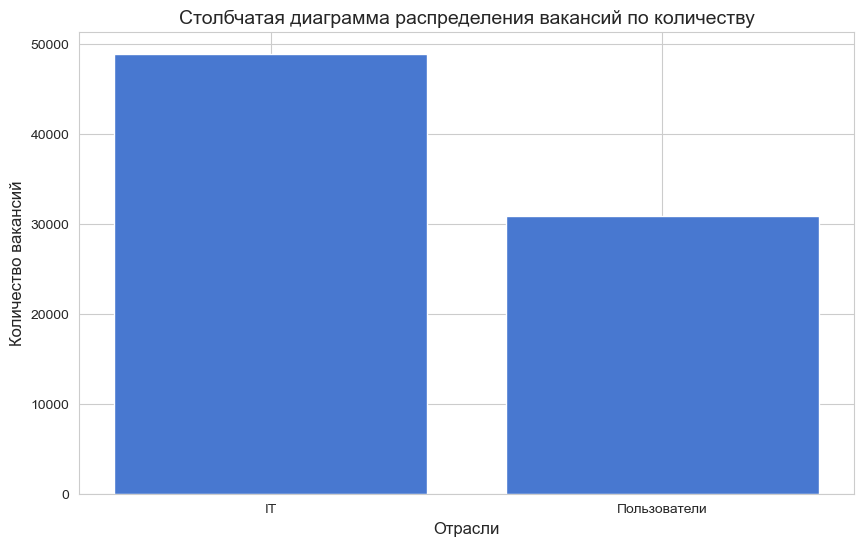

In [29]:
vac_counts = new_df['Категория'].value_counts().sort_values(ascending=False)
plt.bar(vac_counts.index, vac_counts.values)
plt.title('Столбчатая диаграмма распределения вакансий по количеству')
plt.xlabel('Отрасли')
plt.ylabel('Количество вакансий')
plt.show()

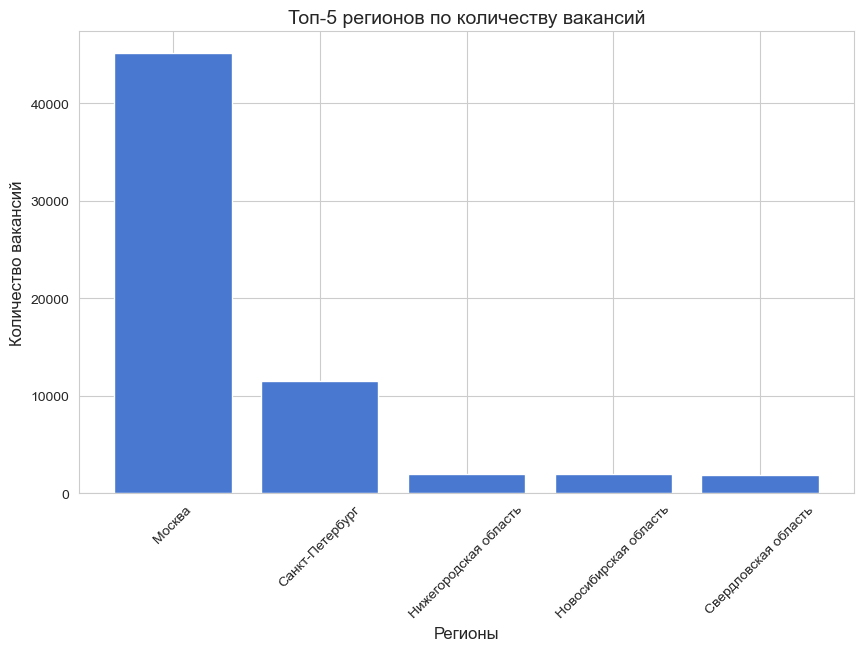

In [30]:
reg_vac_counts = new_df['region_name'].value_counts()[:5].sort_values(ascending=False)
plt.bar(reg_vac_counts.index, reg_vac_counts.values)
plt.title('Топ-5 регионов по количеству вакансий')
plt.xlabel('Регионы')
plt.ylabel('Количество вакансий')
plt.xticks(rotation = 45)
plt.show()

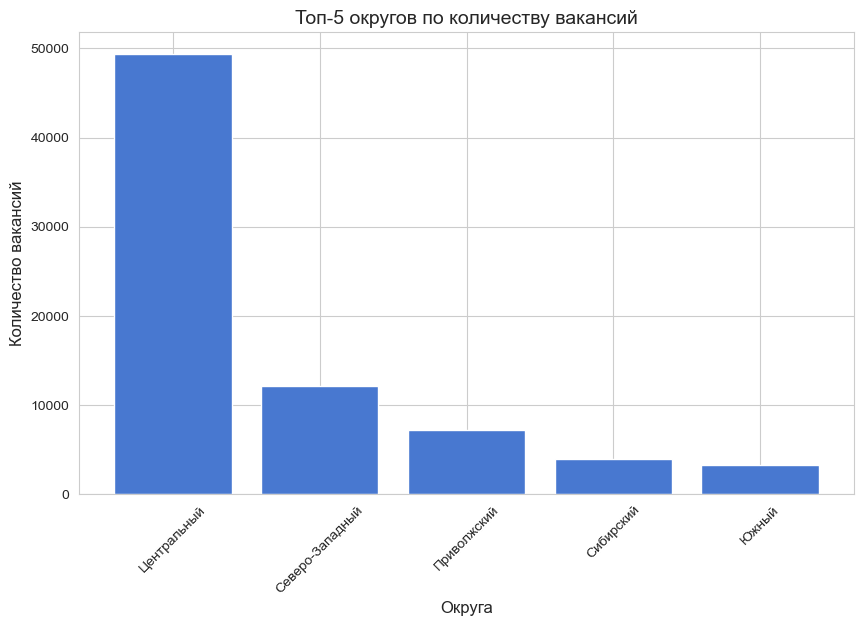

In [31]:
dis_vac_counts = new_df['region_district_name'].value_counts()[:5].sort_values(ascending=False)
plt.bar(dis_vac_counts.index, dis_vac_counts.values)
plt.title('Топ-5 округов по количеству вакансий')
plt.xlabel('Округа')
plt.ylabel('Количество вакансий')
plt.xticks(rotation = 45)
plt.show()

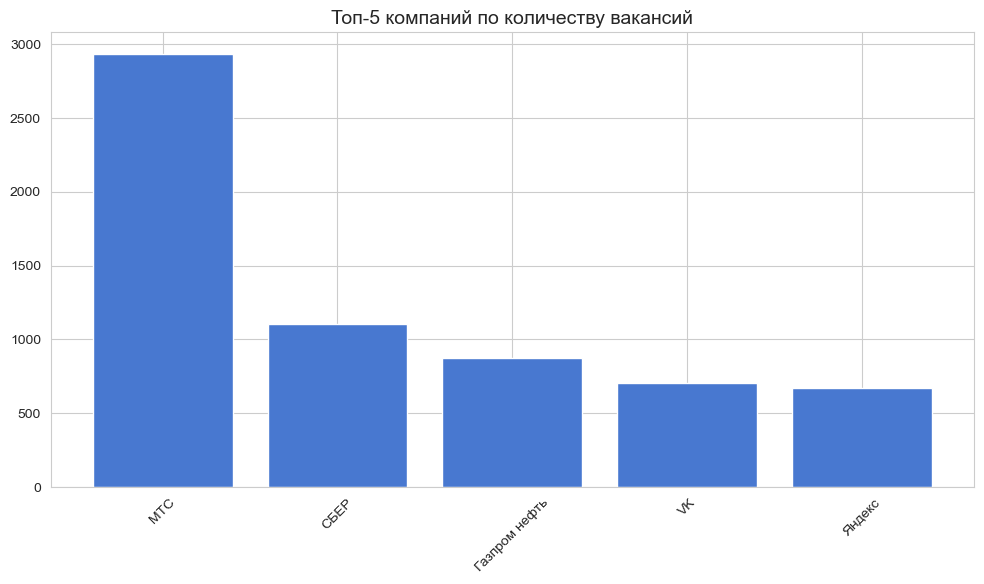

In [32]:
emp_vac_counts = new_df['employer_name'].value_counts()[:5].sort_values(ascending=False)
plt.bar(emp_vac_counts.index, emp_vac_counts.values)
plt.title('Топ-5 компаний по количеству вакансий')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Далее мы провели графический анализ признаков. Из связей можно заметить что ситуация с вакансиями по округам и регионам идентичная. Это из-за того что в столицах этих округов находятся практичнески все вакансии.

# Решение задачи бизнеса

Нам предстоит ответить на следующие ключевые вопросы: 
* В каких секторах экономики наиболее активно ищут специалистов с ИИ-навыками?
* Каковы показатели спроса на ИИ-специалистов по федеральным округам и субъектам РФ?
* В каких компаниях?
* Как меняется общий объем и структура спроса?

Для этого мы найдем самый активный сектор экономики, в котором наиболее активно ищут специалистов с ИИ-навыками. Далее пройдемся по федеральным округам и субъектам РФ. Найдем компании с самым большьшим числом вакансий. И, наконец, проанализируем, как меняется общий объем и структура спроса.

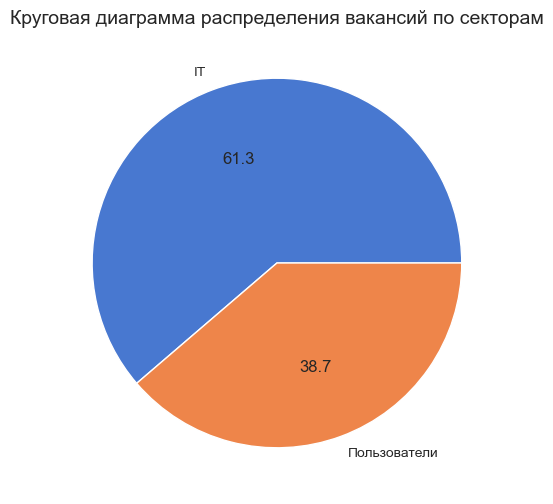

In [33]:
plt.pie(vac_counts, labels = vac_counts.index, autopct='%.1f')
plt.title('Круговая диаграмма распределения вакансий по секторам')
plt.show()

Ответ на первый вопрос мы уже можем дать:
+ IT-сектор занимает 61% всех вакансий. Это подтверждает, что именно IT-компании являются главными драйверами внедрения ИИ. Для соискателя это сигнал, что вход в профессию через IT наиболее вероятен. Для бизнеса из других секторов (например, ритейла) это означает высокую конкуренцию за кадры с IT-гигантами.
+ Поэтому если у соискателя имеются ИИ-навыки, скорее всего будет проще устроиться именно в IT сектор.

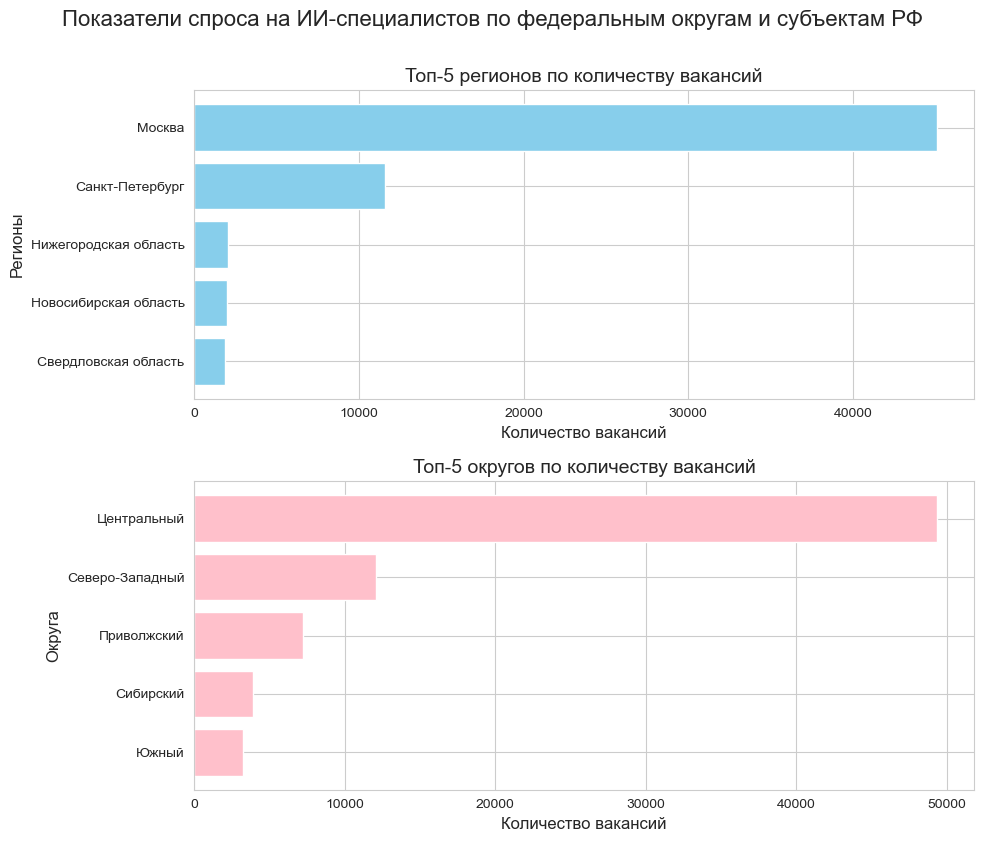

In [34]:
reg_vac_counts_sorted = new_df['region_name'].value_counts()[:5].sort_values(ascending=True)
dis_vac_counts_sorted = new_df['region_district_name'].value_counts()[:5].sort_values(ascending=True)
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
axs[0].barh(reg_vac_counts_sorted.index, reg_vac_counts_sorted.values, color='skyblue')
axs[0].set_title('Топ-5 регионов по количеству вакансий', fontsize=14)
axs[0].set_xlabel('Количество вакансий')
axs[0].set_ylabel('Регионы')

axs[1].barh(dis_vac_counts_sorted.index, dis_vac_counts_sorted.values, color='pink')
axs[1].set_title('Топ-5 округов по количеству вакансий', fontsize=14)
axs[1].set_xlabel('Количество вакансий')
axs[1].set_ylabel('Округа')
plt.tight_layout()
fig.suptitle('Показатели спроса на ИИ-специалистов по федеральным округам и субъектам РФ', y = 1.05, fontsize = 16)
plt.show()

Исходя из данных графиков можно ответить на второй вопрос:
+ Москва и Центральный округ — абсолютные лидеры. Это говорит о сильной централизации ИИ-компетенций. Компаниям из регионов, вероятно, придется делать ставку на удаленную работу или все же растить кадры внутри.

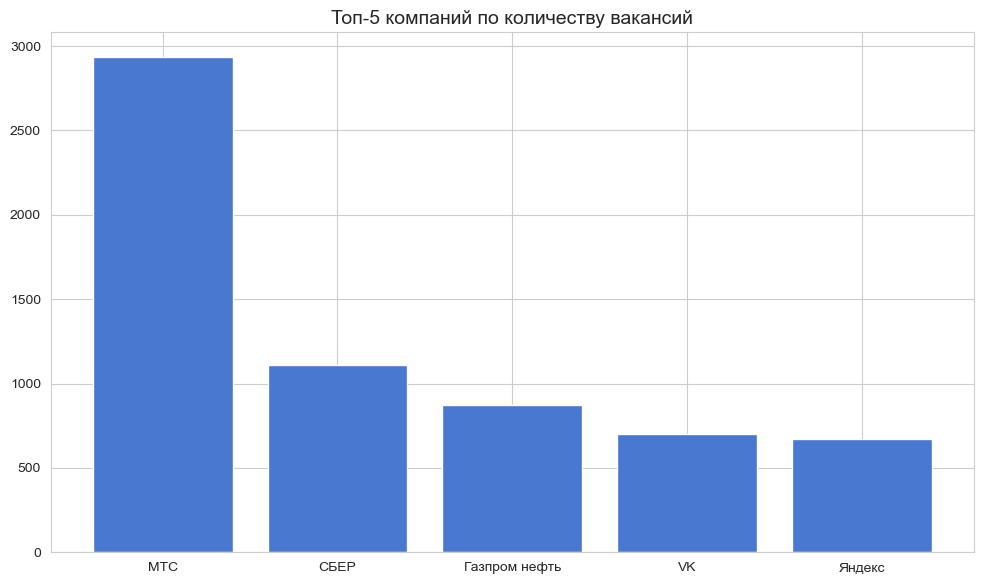

In [35]:
plt.bar(emp_vac_counts.index, emp_vac_counts.values)
plt.title('Топ-5 компаний по количеству вакансий')
plt.tight_layout()
plt.show()

На данном графике мы видим что компания с самым большим количеством вакансий является МТС. У нее 2935 вакансий. Далее идут СБЕР, Газпром нефть, ВК и Яндекс. У них 1108, 874, 702, 670 вакансий соответственно. Тут мы видим что 4 компании из топ-5 относятся к IT сектору, и это нормально. Но 3 место по числу вакансии требющие навыки ИИ заняла Газпром Нефть. Это говорит о том, что компания сделала ставку на современное развитие бизнеса и начала набор кадров с навыками ИИ. Из анализа признака "Название работодателя" можно заметить что навыки ИИ нужны в основном только в большие компании. Маленькие компании только начинают путь развития с искусственным интелектом.

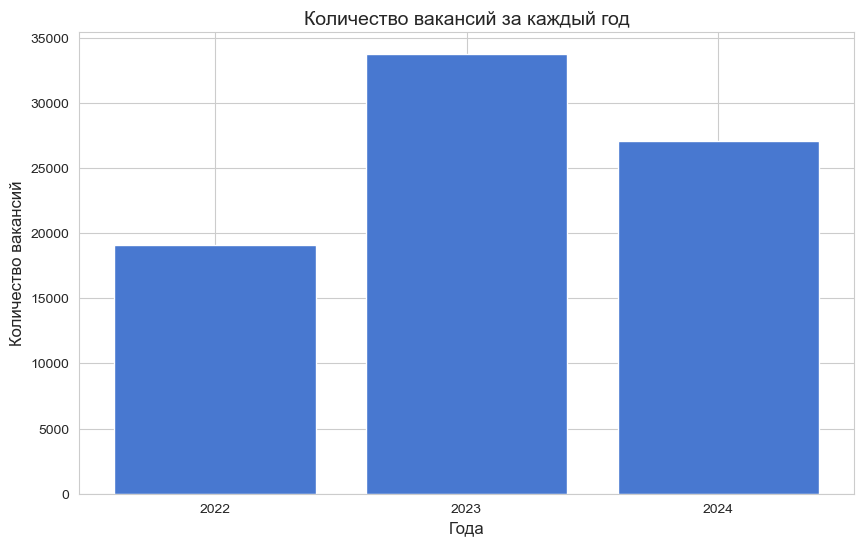

In [37]:
new_df['year'] = new_df['date_published'].dt.year
yearly_counts = new_df['year'].value_counts().sort_index()
years = yearly_counts.index.astype(str)

plt.bar(years, yearly_counts.values)
plt.title('Количество вакансий за каждый год')
plt.xlabel('Года')
plt.ylabel('Количество вакансий')
plt.show()

Для ответа на последний ключевой вопрос мы построили столбчатую диаграмму числа вакансий по годам. Для этого мы выделили каждый год в предоставленном периоде. В итоге у нас получилось, что пик пришелся на 2023 год, затем спад. Однако данные за 2024 год могут быть неполными. Рекомендуется продолжить мониторинг, чтобы понять, является ли это временным явлением или началом стабилизации рынка.

# Выводы

В данном анализе мы провели исследование рынка вакансий, где требуют навыки ИИ. Мы анализировали какие отрасли требуют больше всего кадров с навыками ИИ, какие регионы имеют больше всего вакансий с навыками ИИ, какие компании и в каком количестве ищут сотрудников с навыками ИИ. А также отследили динамику популярности умения работать с ИИ по годам.

## Бизнес рекомендации:

1. Изучив отрасли и количество вакансий, где требуются навыки ИИ готов сделать вывод, что большинство вакансий предоставляют именно IT компании, но в топ-5 компаних пристутствует и одна компания из нефтеперерабатывающей отрасли, что говорит, что в какой отрасли бы заказчик не находился, он может искать сотрудников с навыками ИИ.
2. Изучив регионы, в которых находятся вакансии, я сделал вывод, что лучше всего открыть офис в Москве, тк там находится больше всего вакансий, следовательно и соискателей будет больше.
3. Изучив динамику вакансий с 2022 по 2024 год, я сделал вывод что не стоит сломя говолову перестраивать свои бизнес процессы под ИИ, тк в 2023 популярность вакансий была больше чем 2024, однако актуальность этих навыков не падает, поэтому следить за вакансиями однозначно стоит. 

## Рефлексия

В ходе выполнения этой практики я:
1.  **Научился формулировать бизнес-гипотезы** и проверять их на реальных данных.
2.  **Освоил подход "от вопроса к данным"** — не просто исследовать всё подряд, а искать ответы на конкретные вопросы бизнеса.
3.  **Понял важность визуализации** — график должен не просто быть красивым, а мгновенно доносить ответ.
4.  **Осознал ценность выводов на языке бизнеса.** Цифры ради цифр никому не нужны. Важно переводить их на язык рекомендаций.

**Дальнейшие шаги для углубления исследования:**
- Проанализировать непосредственно колонку `skills` — какие конкретно ИИ-навыки (TensorFlow, PyTorch, NLP) наиболее востребованы.
- Провести анализ зарплатных предложений в разрезе навыков и регионов.
- Сравнить спрос на ИИ-специалистов в России с мировыми трендами (например, по данным международных платформ).